In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import re
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statannotations.Annotator import Annotator

# Color Palette
Colorblindness friendliness was checked on David Nichols' [Coloring for Colorblindness Web Page](https://davidmathlogic.com/colorblind/#%23648FFF-%23785EF0-%23DC267F-%23FE6100-%23FFB000).

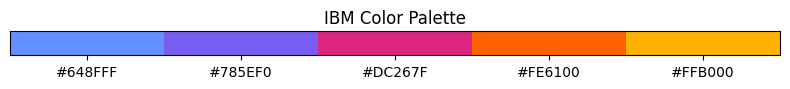

In [3]:
ibm_colors = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000",
]

rgb_colors = [mcolors.to_rgba(c) for c in ibm_colors]

fig, ax = plt.subplots(figsize=(8, 1))

for i, color in enumerate(ibm_colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color))

ax.set_xlim(0, len(ibm_colors))
ax.set_ylim(0, 1)

ax.set_xticks(np.arange(len(ibm_colors)) + 0.5)
ax.set_xticklabels(ibm_colors, ha="center")

ax.set_yticks([])

ax.set_title("IBM Color Palette")

plt.tight_layout()
plt.show()

mycolors = [rgb_colors[0], rgb_colors[2], rgb_colors[4]]

# Load data

In [4]:
figs_root = Path("../figures/adpkd-exploration-screen").resolve().absolute()
if not figs_root.exists():
    figs_root.mkdir(parents=True)

datapath = (
    Path() / "../data/compound_exploration/ADPKD-CpdExplorationScreen_Batch4042_and_Batch4064.csv"
).resolve()

df = pd.read_csv(datapath)

plate_mapping = {"4042_1": 1, "4042_2": 2, "4064_1": 3}
strip_columns = {c: c.replace("plate.layout.info.", "") for c in df.columns if "plate.layout.info." in c}

df = df.assign(plate_id=lambda x: x["ID"].map(plate_mapping)).drop(columns=["ID", "batch.code"])
df = (
    df.rename(columns=strip_columns)
    .rename(columns={"Type": "treatment_type"})
    .drop(columns=["Stimulation solvent", "Treatment solvent", "Treatment 2 solvent"])  # it's all DMSO
)
df.head(1)

,well.name,treatment_type,Stimulant,Stimulant dose,Stimulant unit,Treatment,Treatment concentration,Treatment unit,Treatment 2,Treatment 2 concentration,Treatment 2 unit,obj.Mean(area).um2.meas,obj.Mean(area).meas.npi_plate,Fraction_dead_cells,increase_death_cells_pct,obj.count_corrected.meas,plate_id
0,C03,ref_ctrl,FSK,2.5,uM,rapamycin,0.03,uM,DMSO,0.1,pct,2173.914,37.281319,0.199,-0.95,865,1


## Normalization

In [5]:
readout = "obj.Mean(area).um2.meas"
method = "median"
norm_array = []

for plate in df.plate_id.unique():
    plate_subset = df.query(f"plate_id == {plate}")
    if method == "mean":
        mean_df = (
            plate_subset.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .groupby(["treatment_type", "Stimulant_dose"])[readout]
            .mean()
            .reset_index()
        )
        solv_control = mean_df.query("treatment_type == 'solvent_ctrl' & Stimulant_dose == 0.1")[
            readout
        ].item()
        stim_control = mean_df.query("treatment_type == 'stim_only' & Stimulant_dose == 2.5")[readout].item()

    if method == "median":
        median_df = (
            plate_subset.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .groupby(["treatment_type", "Stimulant_dose"])[readout]
            .median()
            .reset_index()
        )
        solv_control = median_df.query("treatment_type == 'solvent_ctrl' & Stimulant_dose == 0.1")[
            readout
        ].item()
        stim_control = median_df.query("treatment_type == 'stim_only' & Stimulant_dose == 2.5")[
            readout
        ].item()

    denominator = solv_control - stim_control
    val_array = (
        plate_subset[readout]
        .apply(lambda x: x * -1)
        .add(solv_control)
        .div(denominator)
        .apply(lambda x: x * 100)
    )
    norm_array.extend(val_array.tolist())

df["obj.Mean(area).um2.meas_norm"] = norm_array

# Mann-Whitney U test - Boxplots

## Function definition

In [6]:
def plot_single_plate(
    compounds, plate_number, double_treat_cpd, plot_normalized=True, savefig=True, figs_root=None, target=None
):
    target_str = f"-{target}" if target is not None else ""
    spheresize_col = f"obj.Mean(area).um2.meas{'_norm' if plot_normalized else ''}"
    subset = df.query(f"plate_id == {plate_number}")

    idxs = subset.loc[
        (subset["treatment_type"].isin(["solvent_ctrl", "stim_only"])) & (subset["Stimulant"] == "FSK")
    ].index.tolist()
    subset.loc[idxs, "Treatment"] = subset.loc[idxs, "Stimulant"]
    subset.loc[idxs, "Treatment concentration"] = 2.5
    subset.loc[idxs, "Treatment unit"] = "uM"

    subset = subset.assign(
        treat_string=lambda x: x["Treatment"]
        + x["Treatment concentration"].astype(str)
        + " "
        + x["Treatment 2"]
        + x["Treatment 2 concentration"].astype(str)
    ).assign(
        treat_string=lambda x: (
            x["treat_string"]
            .str.replace("DMSO0.1 DMSO0.1", "DMSO 0.2%", regex=False)  # two doses of DMSO 0.1%
            .str.replace("FSK2.5 DMSO0.1", "FSK 2.5µM", regex=False)
            .str.replace("DMSO0.1", "", regex=False)
            .str.replace("0.001", " 0.001µM", regex=False)
            .str.replace("1.0", " 1µM", regex=False)
            .str.replace("0.1 ", " 0.1µM ", regex=False)
            .str.rstrip()
        )
    )

    for cpd in compounds:
        subset_controls = subset.query("treatment_type.isin(['solvent_ctrl', 'stim_only'])")
        subset_controls["Treatment 2"] = "Control"

        subset_cpd = subset.query(f"Treatment == '{cpd}'")
        subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
            lambda x: 0 if x == "DMSO" else 1
        )
        subset_cpd = subset_cpd.sort_values(["Treatment 2 Sort Key", "Treatment concentration"]).drop(
            columns=["Treatment 2 Sort Key"]
        )

        fig, ax = plt.subplots(figsize=(4, 4))
        plot_data = pd.concat([subset_controls, subset_cpd])
        plot_data["Treatment 2"] = plot_data["Treatment 2"].apply(
            lambda x: "+ FSK 2.5µM" if x == "DMSO" else x
        )
        plot_data["Treatment 2"] = plot_data["Treatment 2"].apply(
            lambda x: f"+ {x} + FSK 2.5 µM" if x not in ["Control", "+ FSK 2.5µM"] else x
        )

        def update_treatment_2(row, double_treat_cpd):
            """Add the concentration of the double treatment!! This is for the legend only"""
            return row["Treatment 2"].replace(
                double_treat_cpd, f"{double_treat_cpd} {row['Treatment 2 concentration']}µM"
            )

        doubletreat_search_pattern = re.compile(f"(?=.{cpd})|(?=.{double_treat_cpd})")
        mask = plot_data.treat_string.str.contains(doubletreat_search_pattern, regex=True)
        plot_data.loc[mask, "Treatment 2"] = plot_data.loc[mask].apply(
            update_treatment_2, double_treat_cpd=double_treat_cpd, axis=1
        )

        sns.boxplot(
            data=plot_data,
            x="treat_string",
            y=spheresize_col,
        )

        labels = (
            plot_data[["treat_string", "Treatment 2"]]
            .drop_duplicates()["Treatment 2"]
            .str.replace("Aldosterone", "ALD")
            .str.replace(" + FSK ", "\n+ FSK ")
        )
        uniq_labels = labels.drop_duplicates().tolist()
        # uniq_colors = sns.color_palette("tab10", n_colors=3)
        uniq_colors = mycolors
        colors = [uniq_colors[0]] * 2 + [uniq_colors[1]] * 3 + [uniq_colors[2]] * 3

        legend_handles = [
            mpatches.Patch(facecolor=color, label=label, edgecolor="black", linewidth=0.5)
            for label, color in zip(uniq_labels, uniq_colors)
        ]

        bars = ax.patches
        for bar, color in zip(bars, colors):
            bar.set_facecolor(color)

        ax.legend(
            handles=legend_handles, bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False
        )

        # Prepare pairs for statistical annotation
        control_condition = "FSK 2.5µM"
        treatment_conditions = [f"{cpd} 0.001µM", f"{cpd} 0.1µM", f"{cpd} 1µM"]
        pairs = [(control_condition, cond) for cond in treatment_conditions] + [
            (f"{cpd} 0.001µM {double_treat_cpd} 1µM", f"{cpd} 1µM {double_treat_cpd} 1µM"),
            (f"{cpd} 0.001µM {double_treat_cpd} 1µM", f"{cpd} 0.1µM {double_treat_cpd} 1µM"),
        ]

        # Add statistical annotations
        annotator = Annotator(ax, pairs, data=plot_data, x="treat_string", y=spheresize_col)
        annotator.configure(
            test="Mann-Whitney",
            text_format="star",
            loc="inside",
        )
        annotator.apply_and_annotate()
        labels = [tick.get_text() for tick in ax.get_xticklabels()]
        # get rid of the + doublee_treat_cpd <concentration> part of the string (already in the legend)
        # new_labels = [re.sub(double_treat_cpd + r"\s\d\.?\d*\s?µM", "", x) for x in labels]
        new_labels = labels[:5] + [" ".join([*lab.split()[:2], "+", *lab.split()[2:]]) for lab in labels[5:]]
        ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)

        ax.set_xlabel("")
        ax.set_ylabel(r"Normalized Cyst Swelling (%)")
        ax.set_title(cpd)
        # ax.set_title(f"Plate {plate_number} - {cpd}")

        ax.spines[["right", "top"]].set_visible(False)
        ax.grid(axis="y", alpha=0.5)
        ax.set_axisbelow(True)

        if savefig:
            if figs_root is None:
                figs_root = (Path().parent / "figures").resolve().absolute()
            fig.savefig(
                figs_root / f"boxplot-MannWhitneyU-plate{plate_number}{target_str}_{cpd}_FSK2-5.png",
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
            )
            fig.savefig(
                figs_root / f"boxplot-MannWhitneyU-plate{plate_number}{target_str}_{cpd}_FSK2-5.svg",
                bbox_inches="tight",
                facecolor="none",
            )

        plt.show()

## ADORA1

### Plate 2

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. DPCPX 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.121e-01 U_stat=1.300e+01
DPCPX 0.001µM CPA 1µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.143e-01 U_stat=2.000e+00
FSK 2.5µM vs. DPCPX 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.967e-02 U_stat=6.000e+00
DPCPX 0.001µM CPA 1µM vs. DPCPX 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 2.5µM vs. DPCPX 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.319e-02 U_stat=4.000e+00


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


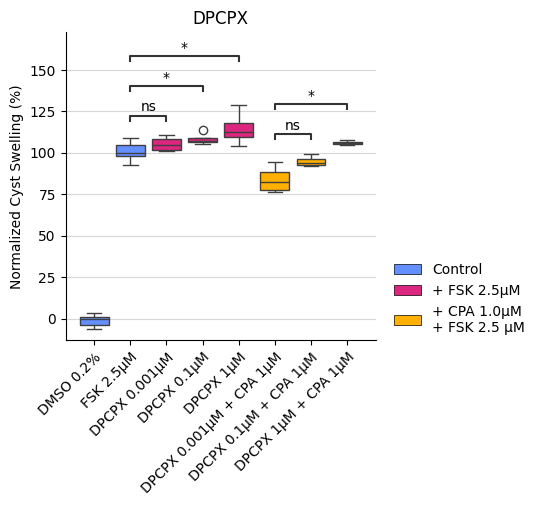

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Capadenoson 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01
Capadenoson 0.001µM CPA 1µM vs. Capadenoson 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=3.000e+00
FSK 2.5µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01
Capadenoson 0.001µM CPA 1µM vs. Capadenoson 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=1.300e+01
FSK 2.5µM vs. Capadenoson 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


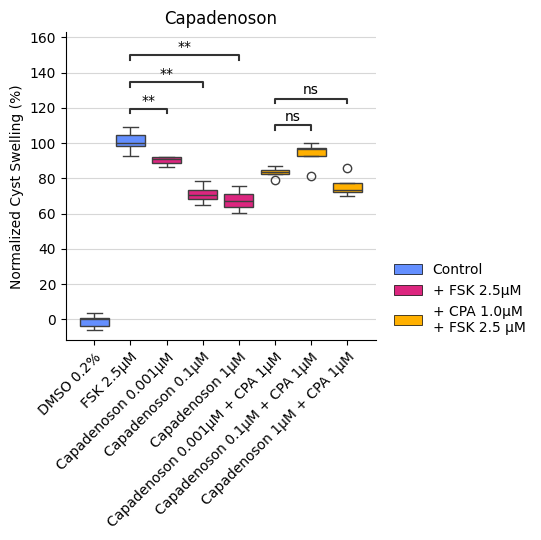

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. MIPS521 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.462e-01 U_stat=3.100e+01
MIPS521 0.001µM CPA 1µM vs. MIPS521 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. MIPS521 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01
MIPS521 0.001µM CPA 1µM vs. MIPS521 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. MIPS521 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.099e-03 U_stat=4.800e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


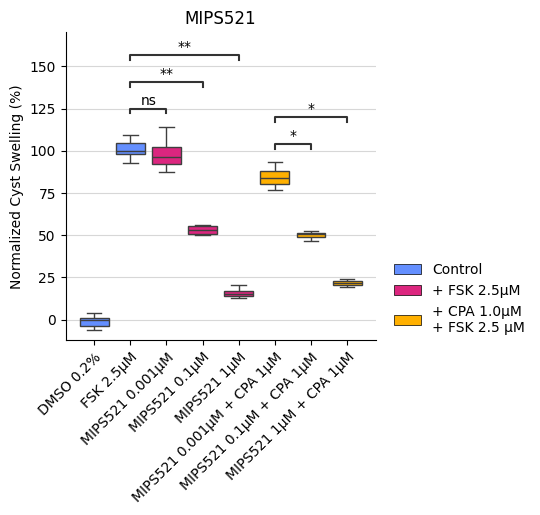

In [7]:
subset = df.query("plate_id == 2")

treatments = [
    "DPCPX",
    "Capadenoson",
    "MIPS521",
]

plot_single_plate(treatments, 2, "CPA", figs_root=figs_root, target="A1R")

### Plate 3

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 824745 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:6.167e-01 U_stat=2.600e+01
824745 0.001µM CPA 1µM vs. 824745 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=1.300e+01
FSK 2.5µM vs. 824745 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.941e-01 U_stat=2.400e+01
824745 0.001µM CPA 1µM vs. 824745 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.857e-01 U_stat=1.100e+01
FSK 2.5µM vs. 824745 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.008e-02 U_stat=5.100e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


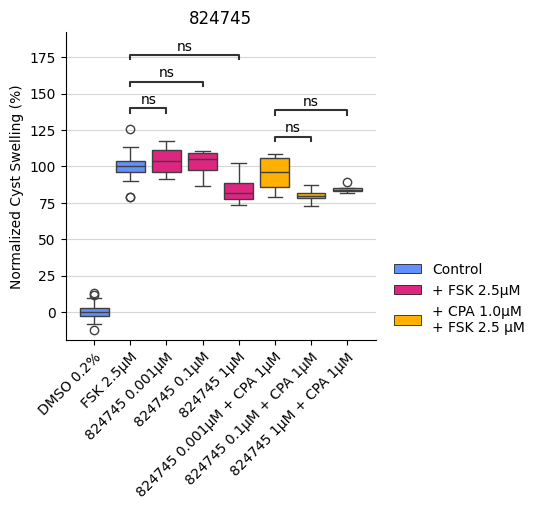

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 1237561 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.485e-01 U_stat=1.900e+01
1237561 0.001µM CPA 1µM vs. 1237561 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:3.429e-01 U_stat=1.200e+01
FSK 2.5µM vs. 1237561 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:9.635e-01 U_stat=3.300e+01
1237561 0.001µM CPA 1µM vs. 1237561 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. 1237561 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.902e-01 U_stat=2.000e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


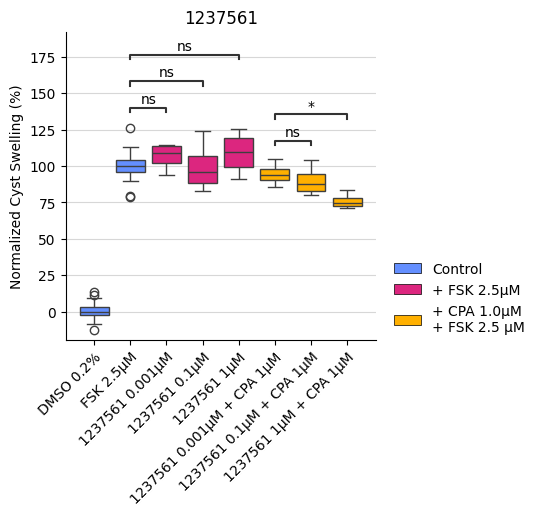

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 1249141 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.372e-01 U_stat=4.100e+01
1249141 0.001µM CPA 1µM vs. 1249141 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.857e-01 U_stat=9.000e+00
FSK 2.5µM vs. 1249141 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:9.635e-01 U_stat=3.300e+01
1249141 0.001µM CPA 1µM vs. 1249141 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=1.300e+01
FSK 2.5µM vs. 1249141 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.890e-03 U_stat=6.100e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


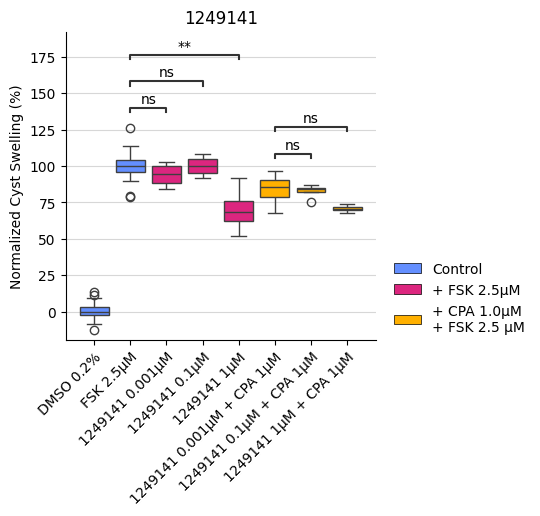

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 1823372 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.188e-02 U_stat=8.000e+00
1823372 0.001µM CPA 1µM vs. 1823372 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:6.857e-01 U_stat=1.000e+01
FSK 2.5µM vs. 1823372 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:6.819e-01 U_stat=2.700e+01
1823372 0.001µM CPA 1µM vs. 1823372 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.143e-01 U_stat=1.400e+01
FSK 2.5µM vs. 1823372 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.902e-01 U_stat=2.000e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


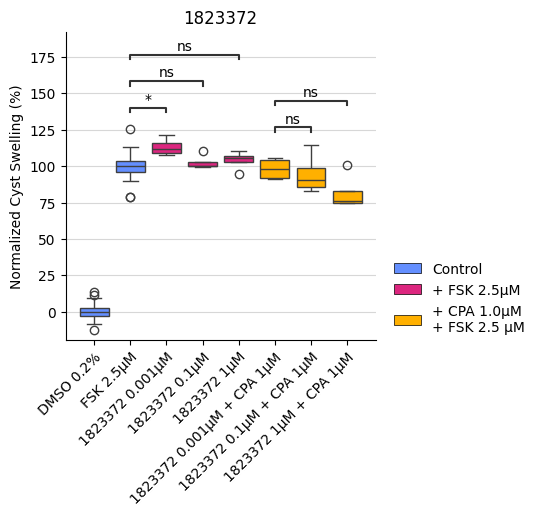

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 22755240 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.775e-01 U_stat=1.700e+01
22755240 0.001µM CPA 1µM vs. 22755240 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=1.300e+01
FSK 2.5µM vs. 22755240 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.941e-01 U_stat=2.400e+01
22755240 0.001µM CPA 1µM vs. 22755240 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.857e-01 U_stat=9.000e+00
FSK 2.5µM vs. 22755240 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:9.948e-02 U_stat=1.400e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


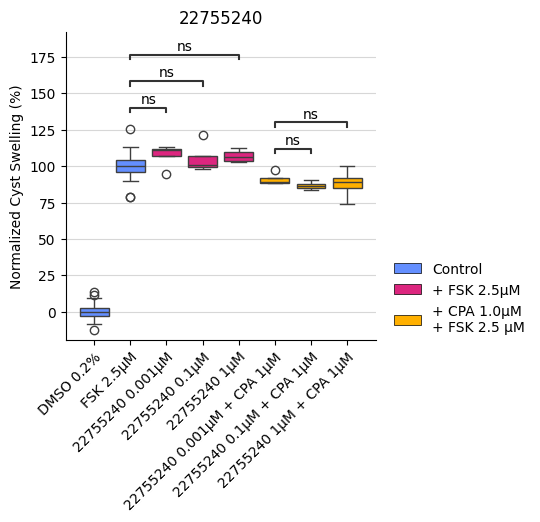

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. 27070328 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.775e-01 U_stat=1.700e+01
27070328 0.001µM CPA 1µM vs. 27070328 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:5.714e-02 U_stat=1.500e+01
FSK 2.5µM vs. 27070328 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.218e-01 U_stat=4.900e+01
27070328 0.001µM CPA 1µM vs. 27070328 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. 27070328 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.115e-02 U_stat=5.800e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


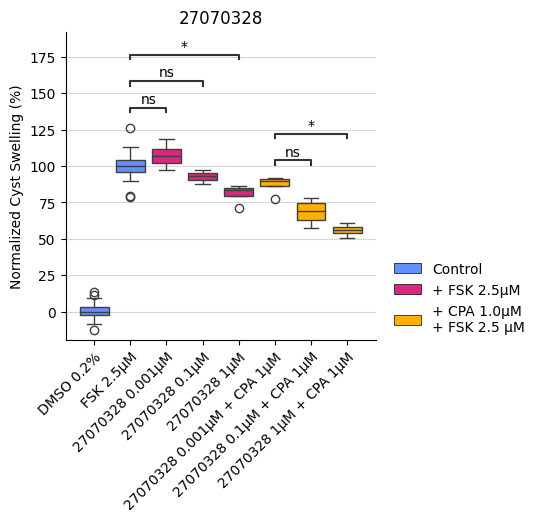

In [8]:
subset = df.query("plate_id == 3")

treatments = ["824745", "1237561", "1249141", "1823372", "22755240", "27070328"]

plot_single_plate(treatments, 3, "CPA", figs_root=figs_root, target="A1R")

## NR3C2

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Finerenone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.218e-01 U_stat=1.500e+01
Finerenone 0.001µM Aldosterone 1µM vs. Finerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:6.857e-01 U_stat=1.000e+01
FSK 2.5µM vs. Finerenone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:6.398e-02 U_stat=1.200e+01
Finerenone 0.001µM Aldosterone 1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Finerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.115e-02 U_stat=6.000e+00


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


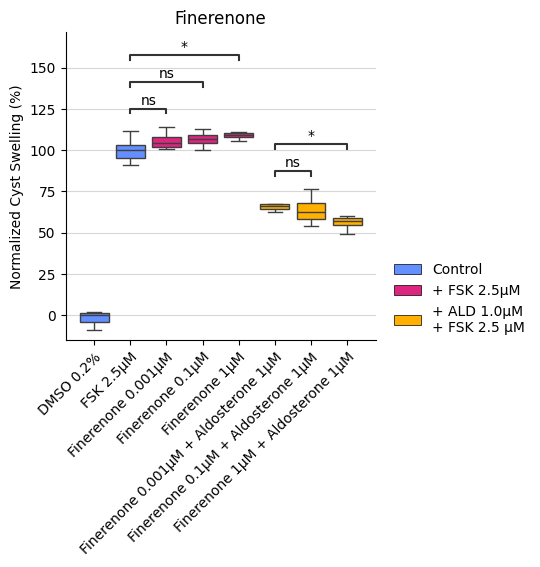

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Esaxerenone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.902e-01 U_stat=2.000e+01
Esaxerenone 0.001µM Aldosterone 1µM vs. Esaxerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.143e-01 U_stat=1.400e+01
FSK 2.5µM vs. Esaxerenone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.916e-01 U_stat=3.000e+01
Esaxerenone 0.001µM Aldosterone 1µM vs. Esaxerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:5.714e-02 U_stat=1.500e+01
FSK 2.5µM vs. Esaxerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.931e-02 U_stat=5.500e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


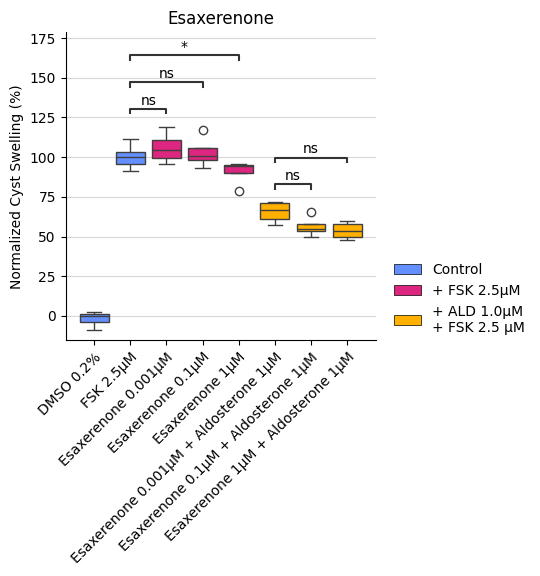

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Apararenone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.941e-01 U_stat=2.400e+01
Apararenone 0.001µM Aldosterone 1µM vs. Apararenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.857e-01 U_stat=5.000e+00
FSK 2.5µM vs. Apararenone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:9.635e-01 U_stat=3.100e+01
Apararenone 0.001µM Aldosterone 1µM vs. Apararenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=1.300e+01
FSK 2.5µM vs. Apararenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:5.536e-01 U_stat=2.500e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


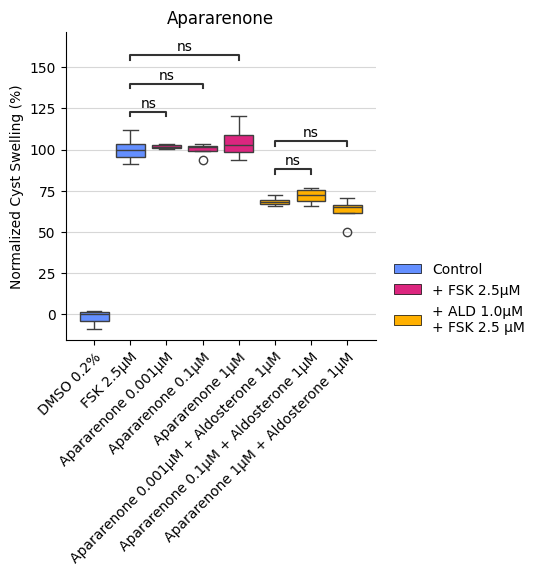

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Benidipine 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:3.847e-01 U_stat=2.200e+01
Benidipine 0.001µM Aldosterone 1µM vs. Benidipine 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.857e-01 U_stat=9.000e+00
FSK 2.5µM vs. Benidipine 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.372e-01 U_stat=2.300e+01
Benidipine 0.001µM Aldosterone 1µM vs. Benidipine 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:3.429e-01 U_stat=4.000e+00
FSK 2.5µM vs. Benidipine 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.902e-01 U_stat=4.400e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


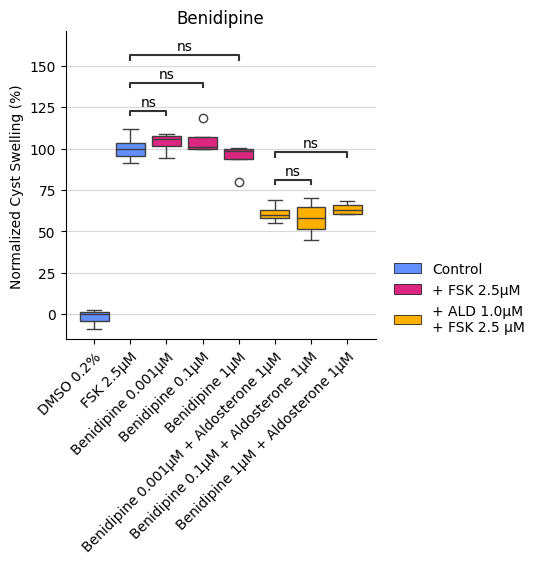

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Z318400112 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.941e-01 U_stat=2.400e+01
Z318400112 0.001µM Aldosterone 1µM vs. Z318400112 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 2.5µM vs. Z318400112 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.482e-01 U_stat=1.600e+01
Z318400112 0.001µM Aldosterone 1µM vs. Z318400112 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.857e-01 U_stat=1.100e+01
FSK 2.5µM vs. Z318400112 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.482e-01 U_stat=1.600e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


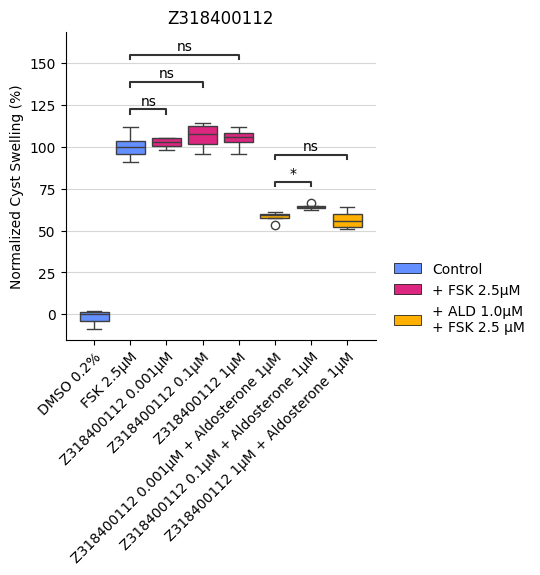

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Z90308949 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.008e-02 U_stat=1.300e+01
Z90308949 0.001µM Aldosterone 1µM vs. Z90308949 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.857e-01 U_stat=9.000e+00
FSK 2.5µM vs. Z90308949 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:9.635e-01 U_stat=3.100e+01
Z90308949 0.001µM Aldosterone 1µM vs. Z90308949 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=1.300e+01
FSK 2.5µM vs. Z90308949 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.482e-01 U_stat=4.800e+01


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


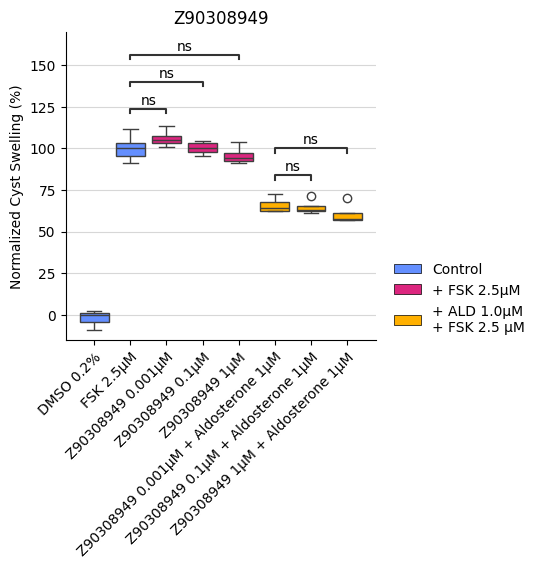

/tmp/ipykernel_1487257/3282918983.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_controls["Treatment 2"] = "Control"
/tmp/ipykernel_1487257/3282918983.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Z95680027 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:5.536e-01 U_stat=3.900e+01
Z95680027 0.001µM Aldosterone 1µM vs. Z95680027 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 2.5µM vs. Z95680027 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:6.167e-01 U_stat=3.800e+01
Z95680027 0.001µM Aldosterone 1µM vs. Z95680027 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 2.5µM vs. Z95680027 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:7.430e-03 U_stat=5.000e+00


/tmp/ipykernel_1487257/3282918983.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


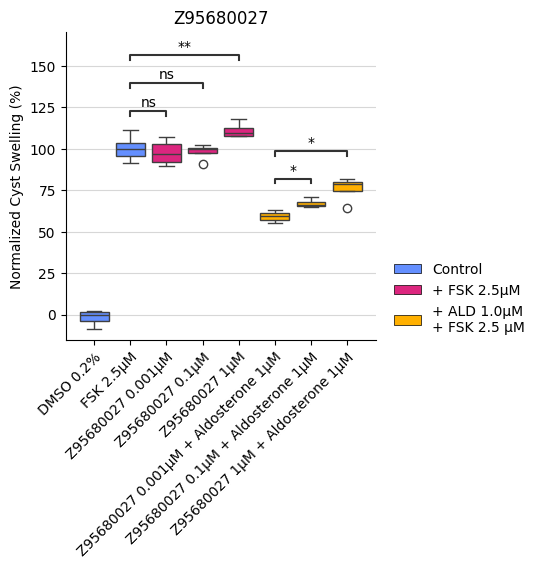

In [9]:
treatments = [
    "Finerenone",
    "Esaxerenone",
    "Apararenone",
    "Benidipine",
    "Z318400112",
    "Z90308949",
    "Z95680027",
]
plot_single_plate(treatments, 1, "Aldosterone", figs_root=figs_root, target="MR")

# Cyst Size v.s. Concentration

## Function definition

In [10]:
import sys

sys.path.append("../03_Target_Validation")

from plot_functions import plot_with_curves

## ADORA1

### Plate 2

/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(


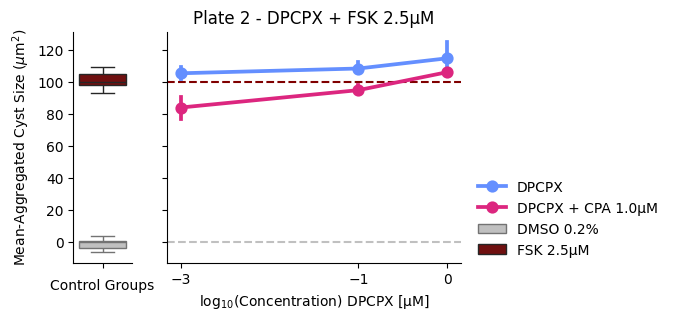

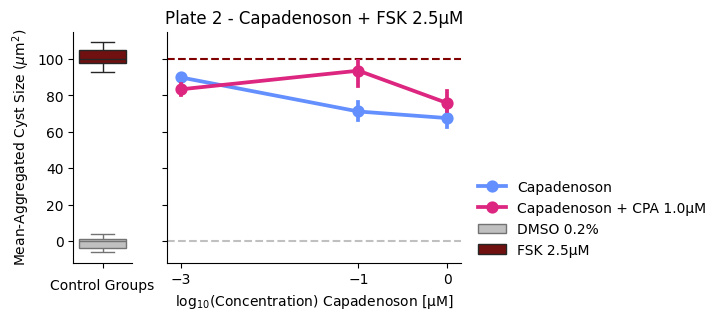

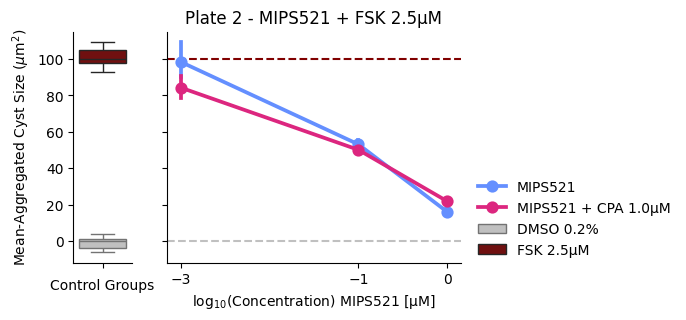

In [11]:
_ = plot_with_curves(df, 2, "DPCPX", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 2, "Capadenoson", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 2, "MIPS521", figs_root=figs_root, target="A1R")

### Plate 3

/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-a

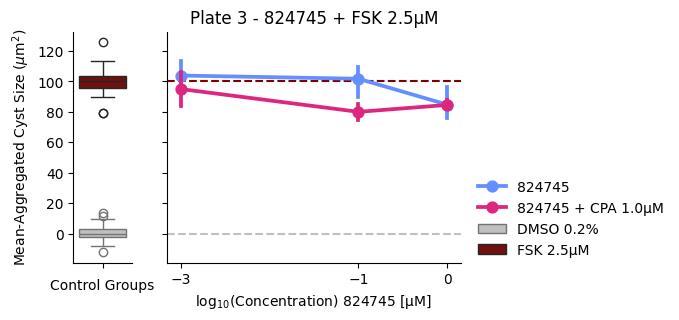

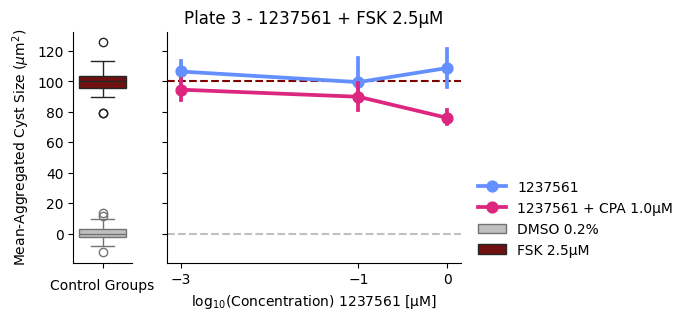

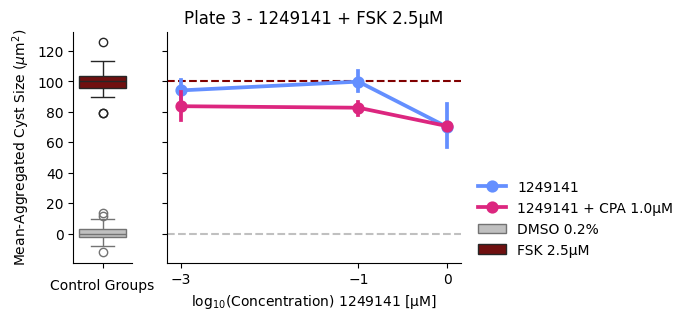

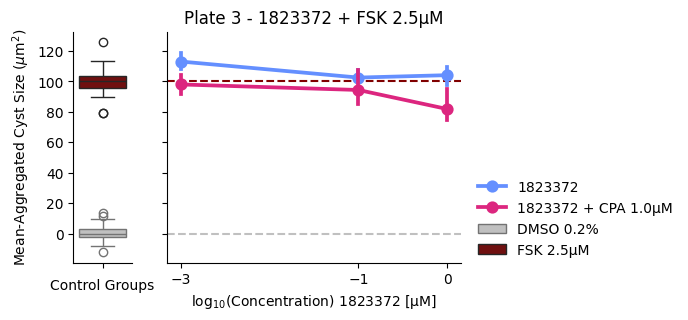

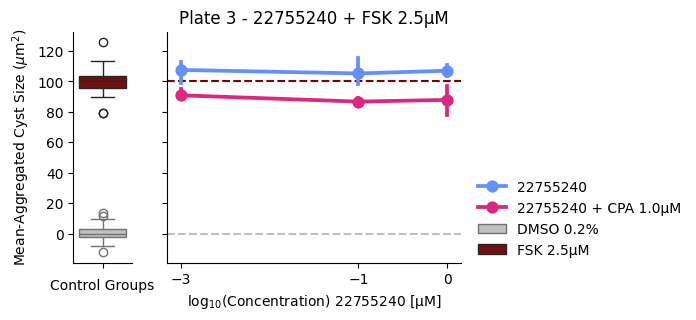

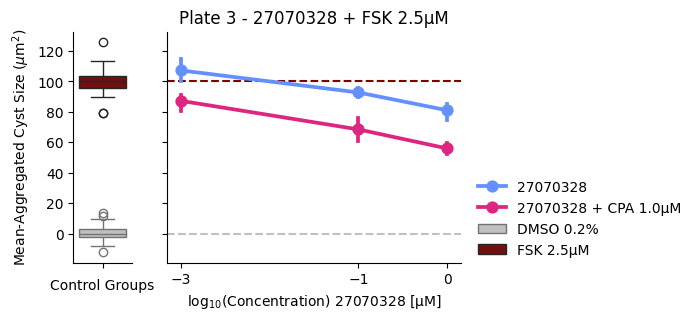

In [12]:
_ = plot_with_curves(df, 3, "824745", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "1237561", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "1249141", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "1823372", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "22755240", figs_root=figs_root, target="A1R")
_ = plot_with_curves(df, 3, "27070328", figs_root=figs_root, target="A1R")

## NR3C2

/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-and-back/04_Virtual_Screening/../03_Target_Validation/plot_functions.py:130: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  seaborn_graphic = sns.pointplot(
/zfsdata/data/david/cyst-to-target-a

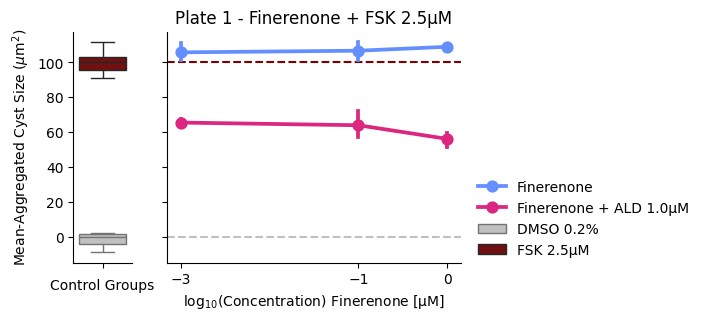

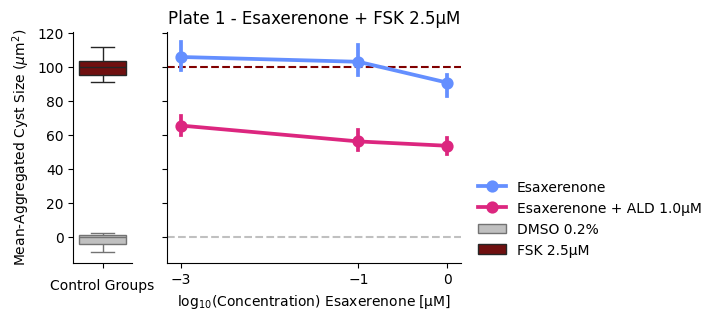

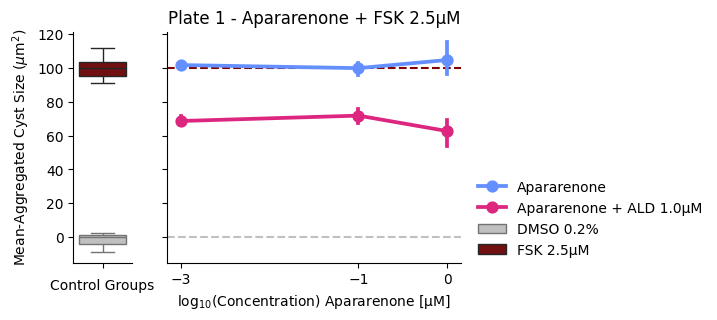

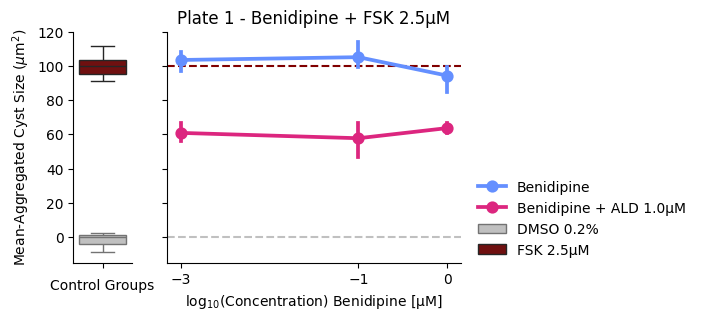

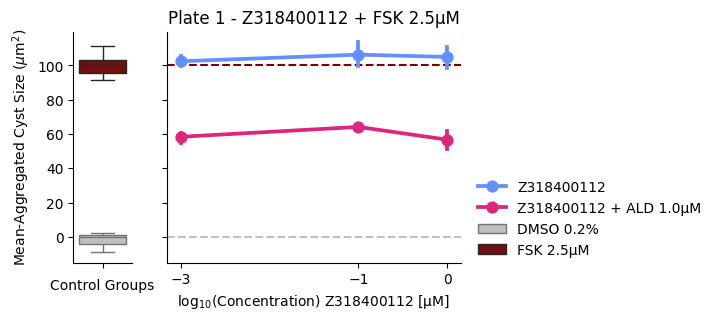

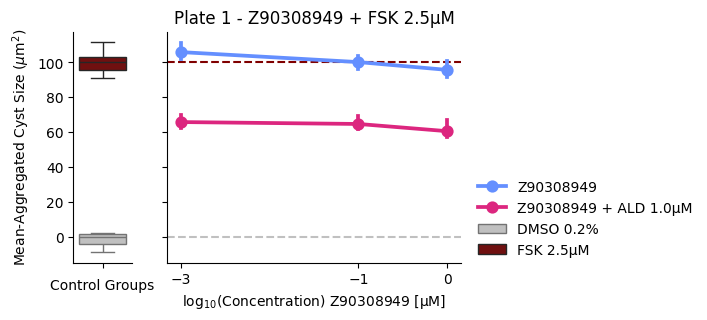

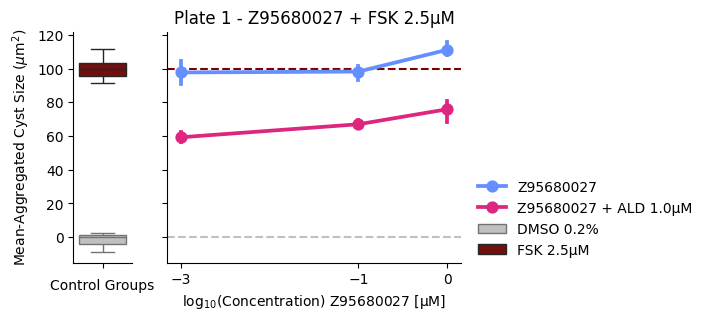

In [13]:
_ = plot_with_curves(df, 1, "Finerenone", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Esaxerenone", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Apararenone", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Benidipine", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Z318400112", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Z90308949", figs_root=figs_root, target="MR")
_ = plot_with_curves(df, 1, "Z95680027", figs_root=figs_root, target="MR")